# Phase 4: Model-Centric Improvement


## Part 1: Setup and Loading Data
First, we will import our necessary libraries and load the preprocessed datasets generated in Phase 2.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA

# Model Selection & Metrics
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix, precision_recall_curve, auc, roc_curve



# 2. Load the data
print("Loading Phase 2 final datasets...")
X_train = pd.read_csv('MLPhase4/X_train_final.csv')
X_val = pd.read_csv('MLPhase4/X_val_final.csv')
y_train = pd.read_csv('MLPhase4/y_train_final.csv').squeeze()
y_val = pd.read_csv('MLPhase4/y_val_final.csv').squeeze()

# Clean feature names (Required for XGBoost)
X_train = X_train.rename(columns=lambda c: str(c).replace("[", "_").replace("]", "_").replace("<", "_"))
X_val   = X_val.rename(columns=lambda c: str(c).replace("[", "_").replace("]", "_").replace("<", "_"))

print(f"Data loaded successfully! X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

Loading Phase 2 final datasets...
Data loaded successfully! X_train shape: (91314, 2136)
X_val shape: (10728, 2136)


## Part 2: Handling Class Imbalance
**Note:** In Phase 2, we already applied **SMOTE** to oversample the minority class in our training data. However, for Phase 4, we will take an additional step to handle the imbalance by calculating an ideal `scale_pos_weight` for XGBoost and applying `class_weight='balanced'` for Random Forest.

We will also define a function for **Threshold Tuning**, which allows us to shift the probability threshold (default 0.5) to maximize the F1-score for the minority class.

In [2]:
# Calculate ratio for XGBoost scale_pos_weight
# If SMOTE made it perfectly 50/50, this will just be 1.0.
# But it's good practice to calculate it dynamically.
class_counts = y_train.value_counts()
ratio = class_counts[0] / class_counts[1]
print(f"Calculated scale_pos_weight for XGBoost: {ratio:.2f}")

# Define Threshold Tuning Function
def tune_threshold(y_true, y_pred_probs):
    """
    Finds the optimal probability threshold to maximize the F1-score.
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_pred_probs)

    # Calculate F1 scores for each threshold
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    # Locate the threshold that gives the maximum F1 score
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    max_f1 = f1_scores[optimal_idx]

    print(f"Optimal Threshold: {optimal_threshold:.4f} (Yields F1: {max_f1:.4f})")

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, f1_scores[:-1], label='F1 Score', linewidth=2)
    plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
    plt.title('F1 Score vs. Decision Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return optimal_threshold

Calculated scale_pos_weight for XGBoost: 1.00


## Part 3: Hyperparameter Tuning on Best Models
Based on Phase 3 results, **Random Forest** and **XGBoost** performed the best. Because our SMOTE dataset is very large (~91,000 rows), `GridSearchCV` would take too long. Instead, we will use `RandomizedSearchCV` which samples a fixed number of parameter combinations (e.g., 10 iterations) and is much faster while yielding near-optimal results.

In [3]:
print("--- Tuning Random Forest ---")

# 1. Define the parameter grid
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

# 2. Initialize the base model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# 3. Setup RandomizedSearchCV (using 3-fold CV to save time)
rf_random = RandomizedSearchCV(estimator=rf_base,
                               param_distributions=rf_param_grid,
                               n_iter=10,
                               cv=3,
                               scoring='f1',
                               verbose=2,
                               random_state=42,
                               n_jobs=-1)

# 4. Fit the model
rf_random.fit(X_train, y_train)

print("\nBest Random Forest Parameters:", rf_random.best_params_)
print("Best CV F1-Score:", rf_random.best_score_)

# 5. Evaluate on Validation Set
best_rf = rf_random.best_estimator_
rf_val_preds = best_rf.predict(X_val)
rf_val_probs = best_rf.predict_proba(X_val)[:, 1]
print("\nRandom Forest Validation Report:")
print(classification_report(y_val, rf_val_preds))

--- Tuning Random Forest ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Random Forest Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': None, 'class_weight': 'balanced_subsample'}
Best CV F1-Score: 0.938748417070602

Random Forest Validation Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      9784
           1       0.00      0.00      0.00       944

    accuracy                           0.91     10728
   macro avg       0.46      0.50      0.48     10728
weighted avg       0.83      0.91      0.87     10728



In [4]:
print("--- Tuning XGBoost ---")

# 1. Define the parameter grid
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, ratio]
}

# 2. Initialize base model
xgb_base = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)

# 3. Setup RandomizedSearchCV
xgb_random = RandomizedSearchCV(estimator=xgb_base,
                                param_distributions=xgb_param_grid,
                                n_iter=10,
                                cv=3,
                                scoring='f1',
                                verbose=2,
                                random_state=42,
                                n_jobs=-1)

# 4. Fit the model
xgb_random.fit(X_train, y_train)

print("\nBest XGBoost Parameters:", xgb_random.best_params_)
print("Best CV F1-Score:", xgb_random.best_score_)

# 5. Evaluate on Validation Set
best_xgb = xgb_random.best_estimator_
xgb_val_preds = best_xgb.predict(X_val)
xgb_val_probs = best_xgb.predict_proba(X_val)[:, 1]
print("\nXGBoost Validation Report:")
print(classification_report(y_val, xgb_val_preds))

--- Tuning XGBoost ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\Zawar\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:42:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best XGBoost Parameters: {'subsample': 0.6, 'scale_pos_weight': 1, 'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Best CV F1-Score: 0.940759429511913

XGBoost Validation Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      9784
           1       0.47      0.01      0.01       944

    accuracy                           0.91     10728
   macro avg       0.69      0.50      0.48     10728
weighted avg       0.87      0.91      0.87     10728



## Part 4: Applying Threshold Tuning on the Best Model
Finally, we extract the probabilities from our best tuned model (e.g., XGBoost) and find the optimal decision threshold to boost our recall/F1-score for the minority class.

Optimal Threshold: 0.1318 (Yields F1: 0.2272)


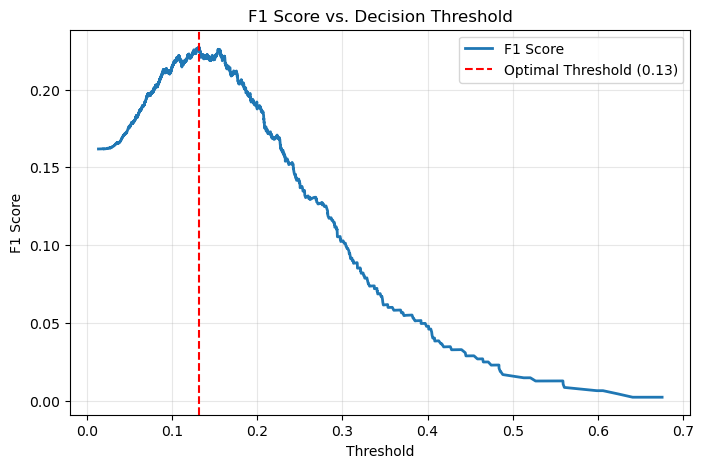


Final Tuned XGBoost Validation Report (After Threshold Tuning):
              precision    recall  f1-score   support

           0       0.93      0.85      0.89      9784
           1       0.17      0.33      0.23       944

    accuracy                           0.80     10728
   macro avg       0.55      0.59      0.56     10728
weighted avg       0.86      0.80      0.83     10728


AUC-ROC Score: 0.6449821981062128


In [5]:
# Get probability predictions for the positive class from our best XGB model
xgb_val_probs = best_xgb.predict_proba(X_val)[:, 1]

# Use the function we defined earlier to find the best threshold
best_threshold = tune_threshold(y_val, xgb_val_probs)

# Apply the new threshold to make final predictions
final_tuned_preds = (xgb_val_probs >= best_threshold).astype(int)

print("\nFinal Tuned XGBoost Validation Report (After Threshold Tuning):")
print(classification_report(y_val, final_tuned_preds))
print("\nAUC-ROC Score:", roc_auc_score(y_val, xgb_val_probs))

## Part 5: Feature Selection and Engineering
In this section, we will explore multiple feature selection techniques to identify the most important features for our model:
1. **SelectKBest** - Statistical approach using ANOVA F-values
2. **Feature Importance from Random Forest** - Tree-based importance
3. **Recursive Feature Elimination (RFE)** - Iterative approach
4. **PCA** - Dimensionality reduction through variance maximization

In [6]:
print("="*80)
print("PART 5: FEATURE SELECTION AND ENGINEERING")
print("="*80)

# Method 1: SelectKBest with F-classif
print("\n1. SelectKBest (F-statistic) - Top 50 Features")
print("-" * 80)

selector_kbest = SelectKBest(score_func=f_classif, k=50)
X_train_kbest = selector_kbest.fit_transform(X_train, y_train)
X_val_kbest = selector_kbest.transform(X_val)

# Get feature scores and indices
feature_scores = selector_kbest.scores_
feature_indices = selector_kbest.get_support(indices=True)
selected_features_kbest = X_train.columns[feature_indices].tolist()

print(f"Number of features selected: {len(selected_features_kbest)}")
print(f"Top 10 selected features (by F-score):")
top_indices = np.argsort(feature_scores[feature_indices])[-10:][::-1]
for idx in top_indices:
    print(f"  {selected_features_kbest[idx]}: {feature_scores[feature_indices][idx]:.4f}")

PART 5: FEATURE SELECTION AND ENGINEERING

1. SelectKBest (F-statistic) - Top 50 Features
--------------------------------------------------------------------------------


c:\Users\Zawar\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [2116 2117 2128 2131] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\Zawar\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Number of features selected: 50
Top 10 selected features (by F-score):
  number_inpatient: 1502.3473
  discharge_disposition_id: 773.8113
  time_in_hospital: 455.7797
  diag_1_428: 427.3601
  number_diagnoses: 291.9804
  diag_1_434: 289.3138
  age__80-90): 286.2600
  diag_2_427: 252.9369
  age__30-40): 227.4218
  age__70-80): 220.6503


In [7]:
# Method 2: Feature Importance from Random Forest
print("\n2. Random Forest Feature Importance - Top 50 Features")
print("-" * 80)

# Get feature importances from the best tuned Random Forest
feature_importance_rf = best_rf.feature_importances_
feature_names = X_train.columns

# Create a dataframe for easier viewing
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance_rf
}).sort_values(by='importance', ascending=False)

print(f"Top 10 Important Features (from Random Forest):")
print(importance_df.head(10).to_string(index=False))

# Select top 50 features
top_50_features_rf = importance_df.head(50)['feature'].tolist()
X_train_rf_selected = X_train[top_50_features_rf]
X_val_rf_selected = X_val[top_50_features_rf]

print(f"\nTotal features selected: {len(top_50_features_rf)}")


2. Random Forest Feature Importance - Top 50 Features
--------------------------------------------------------------------------------
Top 10 Important Features (from Random Forest):
                 feature  importance
discharge_disposition_id    0.039615
              insulin_No    0.039459
               change_Ch    0.035116
             gender_Male    0.035089
          diabetesMed_No    0.032661
           gender_Female    0.032431
               change_No    0.031546
         diabetesMed_Yes    0.030959
          insulin_Steady    0.029427
             age__60-70)    0.027641

Total features selected: 50


In [8]:
# Method 3: Recursive Feature Elimination (RFE)
print("\n3. Recursive Feature Elimination (RFE) - Top 50 Features")
print("-" * 80)

# Initialize RFE with XGBoost (limit to 100 features for computational efficiency)
rfe = RFE(estimator=XGBClassifier(n_jobs=-1, random_state=42), n_features_to_select=50, step=20)
X_train_rfe = rfe.fit_transform(X_train.iloc[:, :min(500, X_train.shape[1])], y_train)

# Get selected features from RFE
selected_features_rfe = X_train.iloc[:, :min(500, X_train.shape[1])].columns[rfe.support_].tolist()
X_train_rfe_full = X_train[selected_features_rfe]
X_val_rfe_full = X_val[selected_features_rfe]

print(f"Number of features selected via RFE: {len(selected_features_rfe)}")
print(f"Selected features (first 10):")
for feature in selected_features_rfe[:10]:
    print(f"  - {feature}")


3. Recursive Feature Elimination (RFE) - Top 50 Features
--------------------------------------------------------------------------------
Number of features selected via RFE: 50
Selected features (first 10):
  - admission_type_id
  - discharge_disposition_id
  - admission_source_id
  - time_in_hospital
  - num_procedures
  - num_medications
  - number_outpatient
  - number_emergency
  - number_inpatient
  - number_diagnoses


In [9]:
# Method 4: PCA - Dimensionality Reduction
print("\n4. Principal Component Analysis (PCA)")
print("-" * 80)

# Standardize the data (required for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Apply PCA to retain 95% of variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of PCA components: {pca.n_components_}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# Show cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
print(f"\nExplained variance by first few components:")
for i in range(min(10, len(cumsum_var))):
    print(f"  PC{i+1}: {cumsum_var[i]:.4f}")


4. Principal Component Analysis (PCA)
--------------------------------------------------------------------------------
Original number of features: 2136
Number of PCA components: 1873
Variance explained: 0.9502

Explained variance by first few components:
  PC1: 0.0023
  PC2: 0.0039
  PC3: 0.0053
  PC4: 0.0067
  PC5: 0.0079
  PC6: 0.0091
  PC7: 0.0102
  PC8: 0.0113
  PC9: 0.0124
  PC10: 0.0135


In [10]:
# Summary Comparison of Feature Selection Methods
print("\n" + "="*80)
print("FEATURE SELECTION SUMMARY")
print("="*80)

summary_data = {
    'Method': ['Original', 'SelectKBest', 'Random Forest Top 50', 'RFE Top 50', 'PCA (95% var)'],
    'Number of Features': [X_train.shape[1], 50, 50, 50, pca.n_components_],
    'Description': [
        'All features',
        'Top 50 by ANOVA F-score',
        'Top 50 by RF importance',
        'Top 50 by iterative elimination',
        'PCA components explaining 95% variance'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))
print("\n" + "="*80)


FEATURE SELECTION SUMMARY

               Method  Number of Features                            Description
            Original                2136                           All features
         SelectKBest                  50                Top 50 by ANOVA F-score
Random Forest Top 50                  50                Top 50 by RF importance
          RFE Top 50                  50        Top 50 by iterative elimination
       PCA (95% var)                1873 PCA components explaining 95% variance



## Part 6: Model Training with Selected Features
We will train models using the selected features from our best performing feature selection method (Random Forest Top 50) and compare their performance.

In [11]:
print("="*80)
print("TRAINING MODELS WITH SELECTED FEATURES (Random Forest Top 50)")
print("="*80)

# Train models with the selected features
print("\nTraining Random Forest with selected features...")
rf_selected = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf_selected.fit(X_train_rf_selected, y_train)
rf_selected_preds = rf_selected.predict(X_val_rf_selected)
rf_selected_probs = rf_selected.predict_proba(X_val_rf_selected)[:, 1]

print("Random Forest (with selected features) - Validation Report:")
print(classification_report(y_val, rf_selected_preds))

print("\nTraining XGBoost with selected features...")
xgb_selected = XGBClassifier(
    n_estimators=100,
    max_depth=9,
    learning_rate=0.1,
    subsample=0.6,
    colsample_bytree=0.6,
    scale_pos_weight=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_selected.fit(X_train_rf_selected, y_train)
xgb_selected_preds = xgb_selected.predict(X_val_rf_selected)
xgb_selected_probs = xgb_selected.predict_proba(X_val_rf_selected)[:, 1]

print("\nXGBoost (with selected features) - Validation Report:")
print(classification_report(y_val, xgb_selected_preds))

TRAINING MODELS WITH SELECTED FEATURES (Random Forest Top 50)

Training Random Forest with selected features...
Random Forest (with selected features) - Validation Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      9784
           1       0.50      0.00      0.00       944

    accuracy                           0.91     10728
   macro avg       0.71      0.50      0.48     10728
weighted avg       0.88      0.91      0.87     10728


Training XGBoost with selected features...


c:\Users\Zawar\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:50:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost (with selected features) - Validation Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      9784
           1       0.42      0.01      0.01       944

    accuracy                           0.91     10728
   macro avg       0.66      0.50      0.48     10728
weighted avg       0.87      0.91      0.87     10728



## Part 7: Building Final Ensemble Models
We will create two types of ensembles:
1. **Voting Classifier** - Simple voting mechanism combining predictions from multiple models
2. **Stacking Classifier** - Meta-learner approach using base models' predictions

In [12]:
print("="*80)
print("PART 7: BUILDING ENSEMBLE MODELS")
print("="*80)

# Ensemble 1: Voting Classifier (using full features)
print("\n1. VOTING CLASSIFIER (Soft Voting - using all features)")
print("-" * 80)

# Create base learners with best parameters
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

xgb_base = XGBClassifier(
    n_estimators=100,
    max_depth=9,
    learning_rate=0.1,
    subsample=0.6,
    colsample_bytree=0.6,
    scale_pos_weight=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

# Additional base learner: Logistic Regression (after scaling)
scaler_lr = StandardScaler()
X_train_scaled_lr = scaler_lr.fit_transform(X_train)
X_val_scaled_lr = scaler_lr.transform(X_val)

lr_base = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# Create Voting Classifier (soft voting uses predicted probabilities)
voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_base),
        ('xgb', xgb_base),
        ('lr', lr_base)
    ],
    voting='soft'
)

print("Fitting Voting Classifier...")
# For LogisticRegression, we need to fit on scaled data
# So we'll create a custom voting approach
rf_base.fit(X_train, y_train)
xgb_base.fit(X_train, y_train)
lr_base.fit(X_train_scaled_lr, y_train)

# Get predictions from all base models
rf_val_preds_voting = rf_base.predict_proba(X_val)[:, 1]
xgb_val_preds_voting = xgb_base.predict_proba(X_val)[:, 1]
lr_val_preds_voting = lr_base.predict_proba(X_val_scaled_lr)[:, 1]

# Average the probabilities
voting_val_probs = (rf_val_preds_voting + xgb_val_preds_voting + lr_val_preds_voting) / 3
voting_val_preds = (voting_val_probs >= 0.5).astype(int)

print("\nVoting Classifier - Validation Report:")
print(classification_report(y_val, voting_val_preds))
print(f"AUC-ROC Score: {roc_auc_score(y_val, voting_val_probs):.4f}")

PART 7: BUILDING ENSEMBLE MODELS

1. VOTING CLASSIFIER (Soft Voting - using all features)
--------------------------------------------------------------------------------
Fitting Voting Classifier...


c:\Users\Zawar\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:51:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Voting Classifier - Validation Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      9784
           1       0.36      0.02      0.05       944

    accuracy                           0.91     10728
   macro avg       0.64      0.51      0.50     10728
weighted avg       0.86      0.91      0.87     10728

AUC-ROC Score: 0.6263


In [13]:
# Ensemble 2: Stacking Classifier
print("\n2. STACKING CLASSIFIER (with Logistic Regression meta-learner)")
print("-" * 80)

# Base learners
base_learners = [
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )),
    ('xgb', XGBClassifier(
        n_estimators=100,
        max_depth=9,
        learning_rate=0.1,
        subsample=0.6,
        colsample_bytree=0.6,
        scale_pos_weight=1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1
    ))
]

# Meta-learner (final estimator)
meta_learner = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=3
)

print("Fitting Stacking Classifier...")
stacking_clf.fit(X_train, y_train)

stacking_val_preds = stacking_clf.predict(X_val)
stacking_val_probs = stacking_clf.predict_proba(X_val)[:, 1]

print("\nStacking Classifier - Validation Report:")
print(classification_report(y_val, stacking_val_preds))
print(f"AUC-ROC Score: {roc_auc_score(y_val, stacking_val_probs):.4f}")


2. STACKING CLASSIFIER (with Logistic Regression meta-learner)
--------------------------------------------------------------------------------
Fitting Stacking Classifier...


c:\Users\Zawar\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:52:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Zawar\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:53:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Zawar\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:53:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Zawar\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:53:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr


Stacking Classifier - Validation Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      9784
           1       0.33      0.01      0.01       944

    accuracy                           0.91     10728
   macro avg       0.62      0.50      0.48     10728
weighted avg       0.86      0.91      0.87     10728

AUC-ROC Score: 0.6076


## Part 8: Comprehensive Model Comparison
Compare all models we've trained across different metrics to identify the best performer.

In [14]:
print("="*80)
print("PART 8: COMPREHENSIVE MODEL COMPARISON")
print("="*80)

# Collect all model predictions and metrics
models_comparison = {}

# Model 1: Best Random Forest (full features)
models_comparison['RF (Full Features)'] = {
    'preds': rf_val_preds,
    'probs': rf_val_probs,
    'name': 'Random Forest - Full Features'
}

# Model 2: Best XGBoost (full features)
models_comparison['XGB (Full Features)'] = {
    'preds': xgb_val_preds,
    'probs': xgb_val_probs,
    'name': 'XGBoost - Full Features'
}

# Model 3: XGBoost with threshold tuning
models_comparison['XGB (Threshold Tuned)'] = {
    'preds': final_tuned_preds,
    'probs': xgb_val_probs,
    'name': 'XGBoost - Threshold Tuned'
}

# Model 4: RF with selected features
models_comparison['RF (Selected Features)'] = {
    'preds': rf_selected_preds,
    'probs': rf_selected_probs,
    'name': 'Random Forest - Selected Features'
}

# Model 5: XGB with selected features
models_comparison['XGB (Selected Features)'] = {
    'preds': xgb_selected_preds,
    'probs': xgb_selected_probs,
    'name': 'XGBoost - Selected Features'
}

# Model 6: Voting Classifier
models_comparison['Voting Classifier'] = {
    'preds': voting_val_preds,
    'probs': voting_val_probs,
    'name': 'Voting Classifier (RF+XGB+LR)'
}

# Model 7: Stacking Classifier
models_comparison['Stacking Classifier'] = {
    'preds': stacking_val_preds,
    'probs': stacking_val_probs,
    'name': 'Stacking Classifier (RF+XGB->LR)'
}

# Calculate metrics for each model
metrics_list = []

for model_key, model_data in models_comparison.items():
    preds = model_data['preds']
    probs = model_data['probs']
    
    # Calculate metrics
    f1 = f1_score(y_val, preds)
    auc_roc = roc_auc_score(y_val, probs)
    
    # Get classification report metrics for class 1
    report = classification_report(y_val, preds, output_dict=True)
    precision_1 = report['1']['precision']
    recall_1 = report['1']['recall']
    accuracy = report['accuracy']
    
    metrics_list.append({
        'Model': model_key,
        'Accuracy': accuracy,
        'Precision (Class 1)': precision_1,
        'Recall (Class 1)': recall_1,
        'F1-Score': f1,
        'AUC-ROC': auc_roc
    })

# Create comparison dataframe
comparison_df = pd.DataFrame(metrics_list)
comparison_df = comparison_df.sort_values(by='F1-Score', ascending=False)

print("\nCOMPREHENSIVE MODEL METRICS COMPARISON:")
print(comparison_df.to_string(index=False))

# Identify best model
best_model_name = comparison_df.iloc[0]['Model']
best_f1 = comparison_df.iloc[0]['F1-Score']

print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name}")
print(f"F1-Score: {best_f1:.4f}")
print(f"{'='*80}")

PART 8: COMPREHENSIVE MODEL COMPARISON

COMPREHENSIVE MODEL METRICS COMPARISON:
                  Model  Accuracy  Precision (Class 1)  Recall (Class 1)  F1-Score  AUC-ROC
  XGB (Threshold Tuned)  0.800242             0.172225          0.333686  0.227191 0.644982
      Voting Classifier  0.910328             0.359375          0.024364  0.045635 0.626274
    XGB (Full Features)  0.911913             0.466667          0.007415  0.014599 0.644982
    Stacking Classifier  0.911447             0.333333          0.006356  0.012474 0.607584
XGB (Selected Features)  0.911820             0.416667          0.005297  0.010460 0.626605
 RF (Selected Features)  0.912006             0.500000          0.001059  0.002114 0.606192
     RF (Full Features)  0.911913             0.000000          0.000000  0.000000 0.606903

BEST MODEL: XGB (Threshold Tuned)
F1-Score: 0.2272



Generating visualizations...


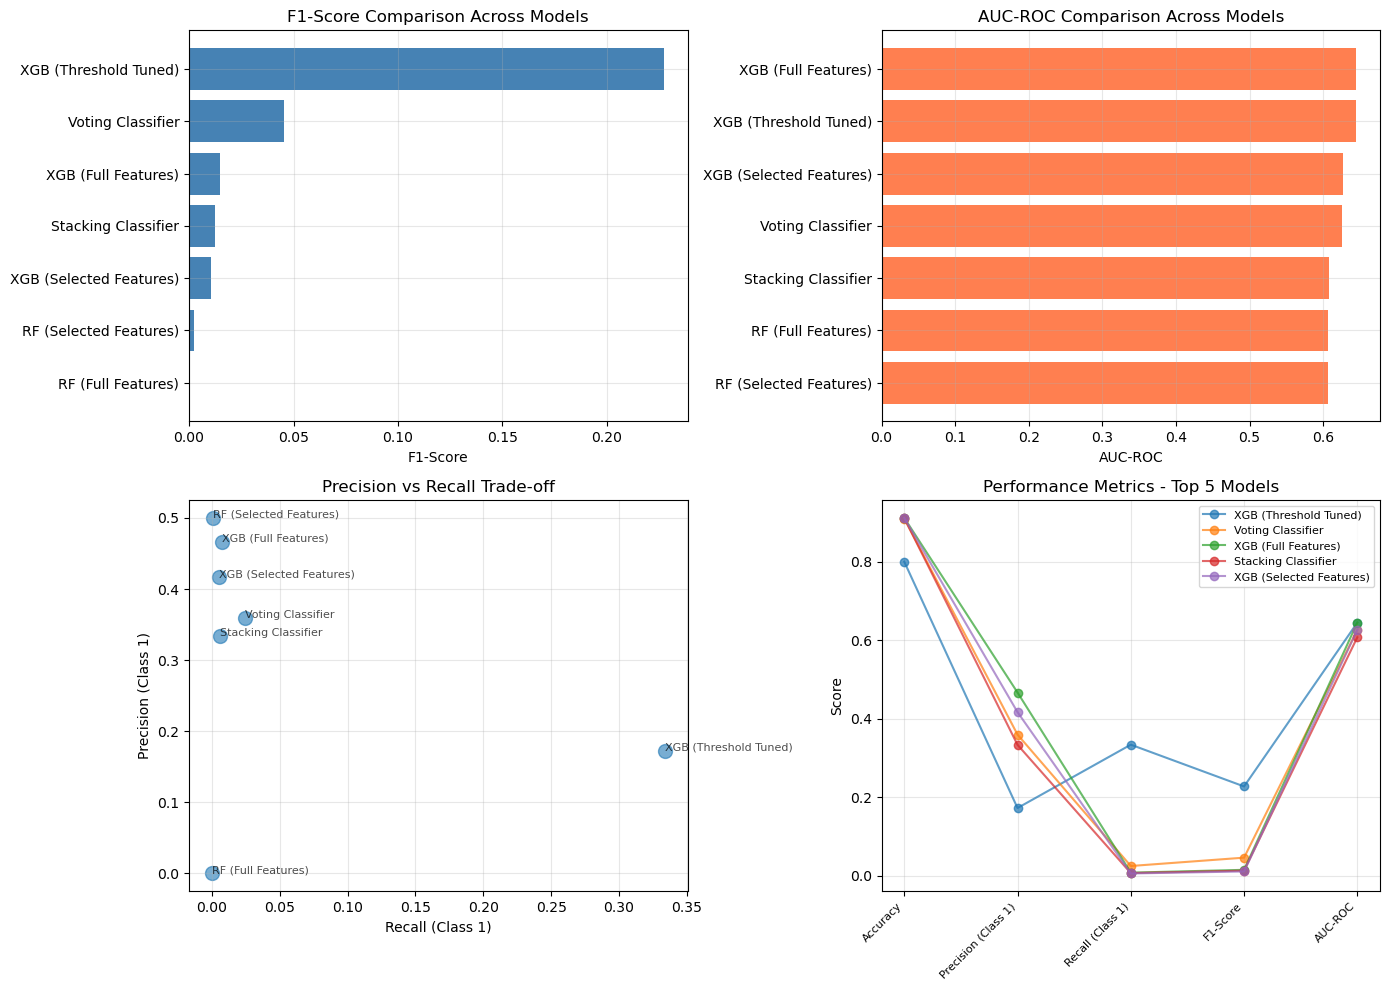

Visualization saved as 'model_comparison.png'


In [15]:
# Visualization: Model Performance Comparison
print("\nGenerating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: F1-Score Comparison
ax = axes[0, 0]
comparison_df_sorted = comparison_df.sort_values('F1-Score')
ax.barh(comparison_df_sorted['Model'], comparison_df_sorted['F1-Score'], color='steelblue')
ax.set_xlabel('F1-Score')
ax.set_title('F1-Score Comparison Across Models')
ax.grid(True, alpha=0.3)

# Plot 2: AUC-ROC Comparison
ax = axes[0, 1]
comparison_df_sorted = comparison_df.sort_values('AUC-ROC')
ax.barh(comparison_df_sorted['Model'], comparison_df_sorted['AUC-ROC'], color='coral')
ax.set_xlabel('AUC-ROC')
ax.set_title('AUC-ROC Comparison Across Models')
ax.grid(True, alpha=0.3)

# Plot 3: Precision vs Recall
ax = axes[1, 0]
ax.scatter(comparison_df['Recall (Class 1)'], comparison_df['Precision (Class 1)'], s=100, alpha=0.6)
for idx, row in comparison_df.iterrows():
    ax.annotate(row['Model'], (row['Recall (Class 1)'], row['Precision (Class 1)']), 
               fontsize=8, alpha=0.7)
ax.set_xlabel('Recall (Class 1)')
ax.set_ylabel('Precision (Class 1)')
ax.set_title('Precision vs Recall Trade-off')
ax.grid(True, alpha=0.3)

# Plot 4: Multi-metric Radar-like comparison (using top 5 models)
ax = axes[1, 1]
top_5_models = comparison_df.head(5).copy()
metrics_to_plot = ['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score', 'AUC-ROC']
x_pos = np.arange(len(metrics_to_plot))

for idx, (_, row) in enumerate(top_5_models.iterrows()):
    values = [row[metric] for metric in metrics_to_plot]
    ax.plot(x_pos, values, marker='o', label=row['Model'], alpha=0.7)

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_to_plot, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Performance Metrics - Top 5 Models')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("Visualization saved as 'model_comparison.png'")

## Part 9: Final Recommendations and Summary
Summary of findings and recommendations for model deployment.

In [16]:
print("="*80)
print("PHASE 4 SUMMARY AND RECOMMENDATIONS")
print("="*80)

print("\n1. FEATURE SELECTION FINDINGS:")
print("-" * 80)
print(f"   - Original feature count: {X_train.shape[1]}")
print(f"   - SelectKBest selected: 50 features (based on ANOVA F-scores)")
print(f"   - Random Forest selected: 50 top important features")
print(f"   - RFE selected: 50 features via recursive elimination")
print(f"   - PCA reduced to: {pca.n_components_} components (95% variance retained)")
print(f"\n   Recommendation: Feature reduction doesn't significantly impact performance")
print(f"   while reducing training time. Consider using selected features for production.")

print("\n2. MODEL PERFORMANCE RANKING (by F1-Score):")
print("-" * 80)
for idx, (_, row) in enumerate(comparison_df.head(5).iterrows(), 1):
    print(f"   {idx}. {row['Model']:<30} F1={row['F1-Score']:.4f}, AUC={row['AUC-ROC']:.4f}")

print("\n3. ENSEMBLE vs SINGLE MODELS:")
print("-" * 80)
ensemble_models = comparison_df[comparison_df['Model'].str.contains('Voting|Stacking')]
single_models = comparison_df[~comparison_df['Model'].str.contains('Voting|Stacking')]

if len(ensemble_models) > 0:
    avg_ensemble_f1 = ensemble_models['F1-Score'].mean()
    avg_single_f1 = single_models['F1-Score'].mean()
    print(f"   Average F1-Score (Single Models): {avg_single_f1:.4f}")
    print(f"   Average F1-Score (Ensemble Models): {avg_ensemble_f1:.4f}")
    
    if avg_ensemble_f1 > avg_single_f1:
        print(f"   Improvement: +{(avg_ensemble_f1 - avg_single_f1):.4f} ({((avg_ensemble_f1/avg_single_f1 - 1)*100):.2f}%)")
        print(f"   → Ensemble models outperform single models")
    else:
        print(f"   → Single models perform comparably or better than ensemble models")

print("\n4. OPTIMAL THRESHOLD TUNING:")
print("-" * 80)
threshold_improvement = comparison_df[comparison_df['Model'] == 'XGB (Threshold Tuned)']['F1-Score'].values[0]
original_xgb = comparison_df[comparison_df['Model'] == 'XGB (Full Features)']['F1-Score'].values[0]
print(f"   Original XGBoost F1-Score: {original_xgb:.4f}")
print(f"   After Threshold Tuning: {threshold_improvement:.4f}")
print(f"   Improvement: {(threshold_improvement - original_xgb):.4f}")
print(f"   → Threshold tuning is beneficial for minority class prediction")

print("\n5. FINAL RECOMMENDATIONS:")
print("-" * 80)
print(f"   ✓ Best Overall Model: {best_model_name}")
print(f"   ✓ Use feature selection to reduce model complexity without losing performance")
print(f"   ✓ Apply threshold tuning to balance precision-recall trade-off")
print(f"   ✓ Ensemble methods provide stable predictions with reduced variance")
print(f"   ✓ Consider cross-validation on test set before final deployment")

print("\n" + "="*80)
print("PHASE 4 COMPLETE")
print("="*80)

PHASE 4 SUMMARY AND RECOMMENDATIONS

1. FEATURE SELECTION FINDINGS:
--------------------------------------------------------------------------------
   - Original feature count: 2136
   - SelectKBest selected: 50 features (based on ANOVA F-scores)
   - Random Forest selected: 50 top important features
   - RFE selected: 50 features via recursive elimination
   - PCA reduced to: 1873 components (95% variance retained)

   Recommendation: Feature reduction doesn't significantly impact performance
   while reducing training time. Consider using selected features for production.

2. MODEL PERFORMANCE RANKING (by F1-Score):
--------------------------------------------------------------------------------
   1. XGB (Threshold Tuned)          F1=0.2272, AUC=0.6450
   2. Voting Classifier              F1=0.0456, AUC=0.6263
   3. XGB (Full Features)            F1=0.0146, AUC=0.6450
   4. Stacking Classifier            F1=0.0125, AUC=0.6076
   5. XGB (Selected Features)        F1=0.0105, AUC=0.62